# EXPLORATORY DATA ANALYSIS

Get the desired features from the dataset, visualize and explore the features, applying any cleaning techniques before using the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels

# Import the dataset and see column names and their types.

df = pd.read_csv('../Data/Lung_and_Bronchus.csv')

print(df.info())
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 579970 entries, 0 to 579969
Data columns (total 20 columns):
 #   Column                                                  Non-Null Count   Dtype
---  ------                                                  --------------   -----
 0   Sex                                                     579970 non-null  str  
 1   Site recode ICD-O-3/WHO 2008                            579970 non-null  str  
 2   Behavior code ICD-O-3                                   579970 non-null  str  
 3   Histologic Type ICD-O-3                                 579970 non-null  int64
 4   RX Summ--Surg Prim Site (1998+)                         579970 non-null  int64
 5   Radiation recode                                        579970 non-null  str  
 6   Chemotherapy recode (yes, no/unk)                       579970 non-null  str  
 7   RX Summ--Scope Reg LN Sur (2003+)                       184846 non-null  str  
 8   Time from diagnosis to treatment in days recode        

- Drop the below columns as they don't contain any predictive value

In [2]:
df.drop(columns=['Site recode ICD-O-3/WHO 2008', 'Behavior code ICD-O-3'])

,Sex,Histologic Type ICD-O-3,RX Summ--Surg Prim Site (1998+),Radiation recode,"Chemotherapy recode (yes, no/unk)",RX Summ--Scope Reg LN Sur (2003+),Time from diagnosis to treatment in days recode,Survival months,Visceral and Parietal Pleural Invasion Recode (2010+),SEER Combined Mets at DX-lung (2010+),SEER cause-specific death classification,Age recode with <1 year olds and 90+,Tumor Size Over Time Recode (1988+),Regional nodes examined (1988+),Regional nodes positive (1988+),Separate Tumor Nodules Ipsilateral Lung Recode (2010+),"Race recode (W, B, AI, API)",Year of diagnosis
0,Male,8140,33,None/Unknown,Yes,4 or more regional lymph nodes removed,058,0047,PL1 or PL2; Invasion of visceral pleura presen...,No,Alive or dead of other cause,65-69 years,070,16,9,None; No intrapulmonary mets; Foci in situ/min...,White,2018
1,Female,8010,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0003,Not documented; No resection of primary; Not a...,No,Alive or dead of other cause,75-79 years,030,0,98,None; No intrapulmonary mets; Foci in situ/min...,White,2011
2,Female,8140,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0029,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,030,0,98,None; No intrapulmonary mets; Foci in situ/min...,Black,2010
3,Female,8140,0,Beam radiation,Yes,NaN,019,0027,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,109,0,98,Separate nodules of same hist type in ipsilate...,White,2016
4,Female,8041,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0000,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,0,98,Not documented; Primary tumor is in situ; Not ...,Black,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579965,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,Black,2021
579966,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),80-84 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021
579967,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),85-89 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021
579968,Male,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021


### Missing Values
In the below cell, we see that the 2 features *RX Summ--Scope Reg LN Sur (2003+)* and *SEER Combined Mets at DX-lung (2010+)* both contain 'NaN' values. These 'NaN' values are substitutions for blank cells/entries. It's important to consider that these blank values are separate from the entries representing 'unknown' or 'N/A', and thus I feel that it would be incorrect to simply group these values together. For the former feature mentioned, I have elected to remove the feature entirely, as over 68% of entries are blank, and this combined with a lack of documentation on why entries are left blank concerns me with regards to its reliability. For *SEER Combined Mets at DX-lung (2010+)*, I decided to remove the data entries containing those blank entries, as only a very small portion of entries have that blank entry.

In [3]:
## Handle missing values in each category

#see unqiue values at column with missing values
print(df['RX Summ--Scope Reg LN Sur (2003+)'].unique())
print(df['SEER Combined Mets at DX-lung (2010+)'].unique())

#Handle missing values
df = df.dropna(subset=['SEER Combined Mets at DX-lung (2010+)'])
df = df.drop(columns='RX Summ--Scope Reg LN Sur (2003+)')

<StringArray>
[                    '4 or more regional lymph nodes removed',
                                                          nan,
           'Biopsy or aspiration of regional lymph node, NOS',
                        '1 to 3 regional lymph nodes removed',
                                  'Unknown or not applicable',
             'Number of regional lymph nodes removed unknown',
                                 'Sentinel lymph node biopsy',
 'Sentinel node biopsy and lym nd removed same/unstated time',
    'Sentinel node biopsy and lym nd removed different times']
Length: 9, dtype: str
<StringArray>
['No', 'Yes', 'Unknown', nan]
Length: 4, dtype: str


### Data Transformation
- Convert the below features from string values to number values (Int64). This makes them easier to work with, and prepares them for future transformation/preprocessing. Before handling unknown/missing values, I will visualize the variables. Doing so will allow to better understand the distribution of known values for each feature before deciding on how to impute them.

- For the age groups, I elect to use the midpoint of each age group to preserve the distance between each age group.

In [4]:
print(df.iloc[:, [7, 8]].head(10))

col = 'Time from diagnosis to treatment in days recode'
df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

df['Survival months'] = pd.to_numeric(df['Survival months'], errors="coerce").astype("Int64")

col = 'Tumor Size Over Time Recode (1988+)'
df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

  Time from diagnosis to treatment in days recode Survival months
0                                             058            0047
1                             Unable to calculate            0003
2                             Unable to calculate            0029
3                                             019            0027
4                             Unable to calculate            0000
5                                             039            0052
6                                             045            0012
7                                             023            0047
8                                             148            0016
9                             Unable to calculate            0000


In [5]:
print(df.iloc[:, 12].unique())

def age_to_midpoint(age):
    lower = int(age[:2])

    if lower > 0:
        return lower + 2
    return lower

    
col = 'Age recode with <1 year olds and 90+'

df[col] = df[col].apply(age_to_midpoint)

df[col].unique()


<StringArray>
['65-69 years', '75-79 years', '80-84 years', '85-89 years', '55-59 years',
 '60-64 years',   '90+ years', '70-74 years', '50-54 years', '45-49 years',
 '40-44 years', '35-39 years', '30-34 years', '25-29 years', '20-24 years',
 '15-19 years', '10-14 years',    '00 years', '05-09 years', '01-04 years']
Length: 20, dtype: str


array([67, 77, 82, 87, 57, 62, 92, 72, 52, 47, 42, 37, 32, 27, 22, 17, 12,
        0,  7,  3])

### Univariate Analysis

- Visualize the features individually to better understand which values are most common/rare, skewness, etc.

In [6]:
categorical = [
    'Sex',
    'Age recode with <1 year olds and 90+',
    'Histologic Type ICD-O-3',
    'RX Summ--Surg Prim Site (1998+)',
    'Radiation recode',
    'Chemotherapy recode (yes, no/unk)',
    'Visceral and Parietal Pleural Invasion Recode (2010+)',
    'SEER Combined Mets at DX-lung (2010+)',
    'SEER cause-specific death classification',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)',
    'Race recode (W, B, AI, API)'
]

categorical_labels = {
    'Sex': 'Sex',
    'Age recode with <1 year olds and 90+': 'Age',
    'Histologic Type ICD-O-3': 'Histologic Type',
    'RX Summ--Surg Prim Site (1998+)': 'Surgery site',
    'Radiation recode': 'Radiation',
    'Chemotherapy recode (yes, no/unk)': 'Chemotherapy',
    'Visceral and Parietal Pleural Invasion Recode (2010+)': 'Pleural Invasion',
    'SEER Combined Mets at DX-lung (2010+)': 'Mets at Diagnosis',
    'SEER cause-specific death classification': 'Cause-Specific Death',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)': 'Separate Tumor Nodules',
    'Race recode (W, B, AI, API)': 'Race'
}

numerical = [
    'Time from diagnosis to treatment in days recode',
    'Survival months',
    'Tumor Size Over Time Recode (1988+)',
    'Regional nodes examined (1988+)',
    'Regional nodes positive (1988+)',
    'Year of diagnosis'
]

numerical_labels = {
    'Time from diagnosis to treatment in days recode': 'Time From Diagnosis to Treatment',
    'Year of diagnosis': 'Diagnosis Year',
    'Tumor Size Over Time Recode (1988+)': 'Tumor Size',
    'Regional nodes examined (1988+)': 'Nodes Examined',
    'Regional nodes positive (1988+)': 'Nodes Positive',
    'Survival months': 'Survival Months'
}

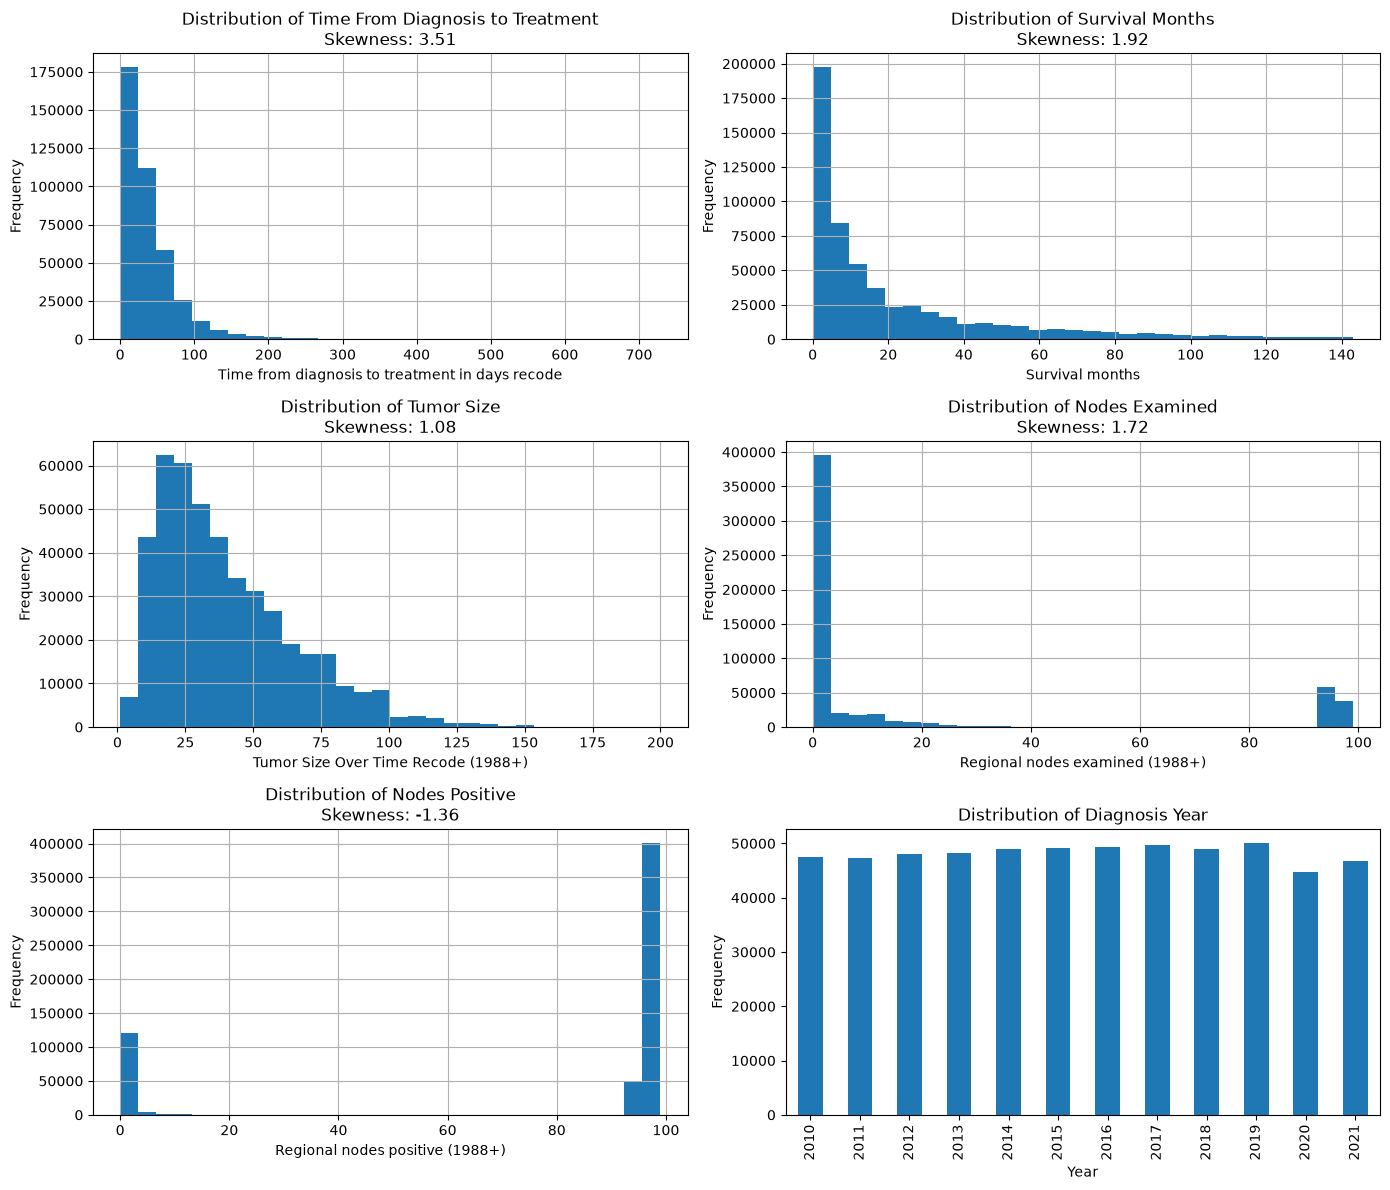

In [7]:


fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerical):

    if col == 'Year of diagnosis':
        df[col].value_counts().sort_index().plot(
            kind='bar',
            ax=ax
        )
        ax.set_xlabel('Year')
        ax.set_title(f'Distribution of {numerical_labels[col]}')

    else:
        df[col].hist(
            bins=30,
            ax=ax
        )
        ax.set_xlabel(col)

        skew = df[col].skew()
        ax.set_title(f'Distribution of {numerical_labels[col]}\nSkewness: {skew:.2f}')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation of numerical features

- For the charts representing continuous features (Time from diagnosis to treatment, survival months, tumor size), I will use an automated power transformer to normalize them (after creating training/test split).
- For regional nodes examined/positive, more probing will be needed to determine the cause for their distributions. My initial suspicion is that many of the entries are that there were no nodes examined. As per the ['SEER Research Data Record Description'](https://seer.cancer.gov/data-software/documentation/seerstat/nov2025/TextData.FileDescription-nov2025.pdf), for *regional nodes examined (1988+)*, 0 represents 'no nodes were examined.' For *regional nodes positive (1988+)*, 98 represents the same. These are the corresponding values that are dominating their respective graphs above.

In [8]:
df[['Regional nodes examined (1988+)', 'Regional nodes positive (1988+)']].value_counts()


Regional nodes examined (1988+)  Regional nodes positive (1988+)
0                                98                                 370738
95                               95                                  49761
99                               99                                  28610
95                               0                                    8741
1                                1                                    5587
                                                                     ...  
62                               7                                       1
85                               0                                       1
36                               33                                      1
41                               22                                      1
30                               22                                      1
Name: count, Length: 1032, dtype: int64

To handle the above values, I will create 2 new features to represent values greater than 90 in each of the above features. This is because only values between 0-89 represent exact counts of nodes that were examined/postiive. The other values represent special categories, and I feel that these can still have predictive value. For the known values (0-89), I will visualize them alone excluding the special values to determine the skewness, and then impute compatible special values accordingly.

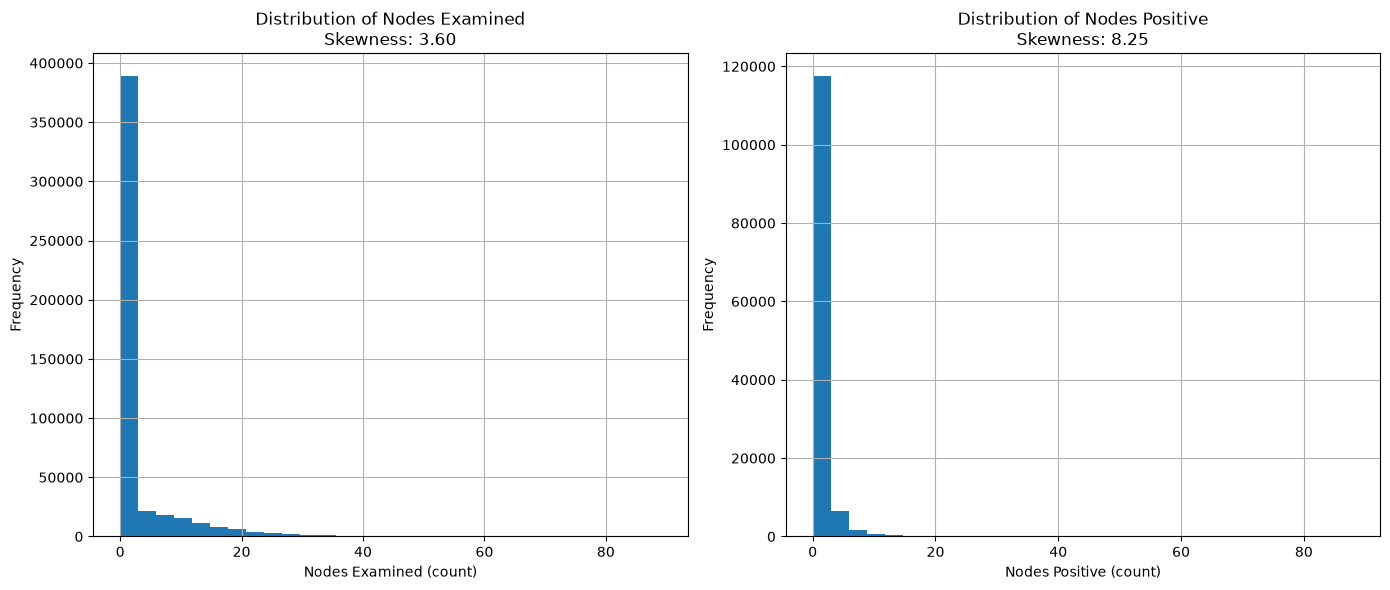

In [9]:
# create new columns
# remove values from original columns so they are N/A
# visualize original columns
# Adjust based on skewness
# Impute N/A values in original categories


new_col_pos = 'Regional nodes positive treatment'
col_pos = 'Regional nodes positive (1988+)'

df[new_col_pos] = df[col_pos].where(df[col_pos] >= 90)
df[col_pos] = df[col_pos].where(df[col_pos] <= 89)


new_col_ex = 'Regional nodes examined treatment'
col_ex = 'Regional nodes examined (1988+)'

df[new_col_ex] = df[col_ex].where(df[col_ex] >= 90)
df[col_ex] = df[col_ex].where(df[col_ex] <= 89)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

regional_nodes_cols = [col_ex, col_pos]

for ax, col in zip(axes, regional_nodes_cols):
    df[col].hist(
        bins=30,
        ax=ax
    )
    ax.set_xlabel(f'{numerical_labels[col]} (count)')

    skew = df[col].skew()
    ax.set_title(f'Distribution of {numerical_labels[col]}\nSkewness: {skew:.2f}')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

As seen in the above charts, both regional node categories are heavily rightly skewed in the context of cases with an exact amount of regional nodes examined. A power transform will need to be done after splitting the data.

In [10]:
#visualize categorical features

for col in categorical:
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(normalize=True, dropna=False) * 100

    result = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(2)
    })

    print(f'\n--- {categorical_labels[col]} ---')
    print(result)


--- Sex ---
         Count  Percentage
Sex                       
Male    298056       51.46
Female  281126       48.54

--- Age ---
                                       Count  Percentage
Age recode with <1 year olds and 90+                    
72                                    102400       17.68
67                                     96371       16.64
77                                     90757       15.67
62                                     74249       12.82
82                                     67051       11.58
57                                     50161        8.66
87                                     38114        6.58
52                                     25844        4.46
92                                     16857        2.91
47                                     10394        1.79
42                                      3865        0.67
37                                      1636        0.28
32                                       768        0.13
27         

### Bivariate Analysis
#### Numerical vs Numerical

- Pearson's r shows linear correlation, Spearman's p shows monotonic non-linear correlation



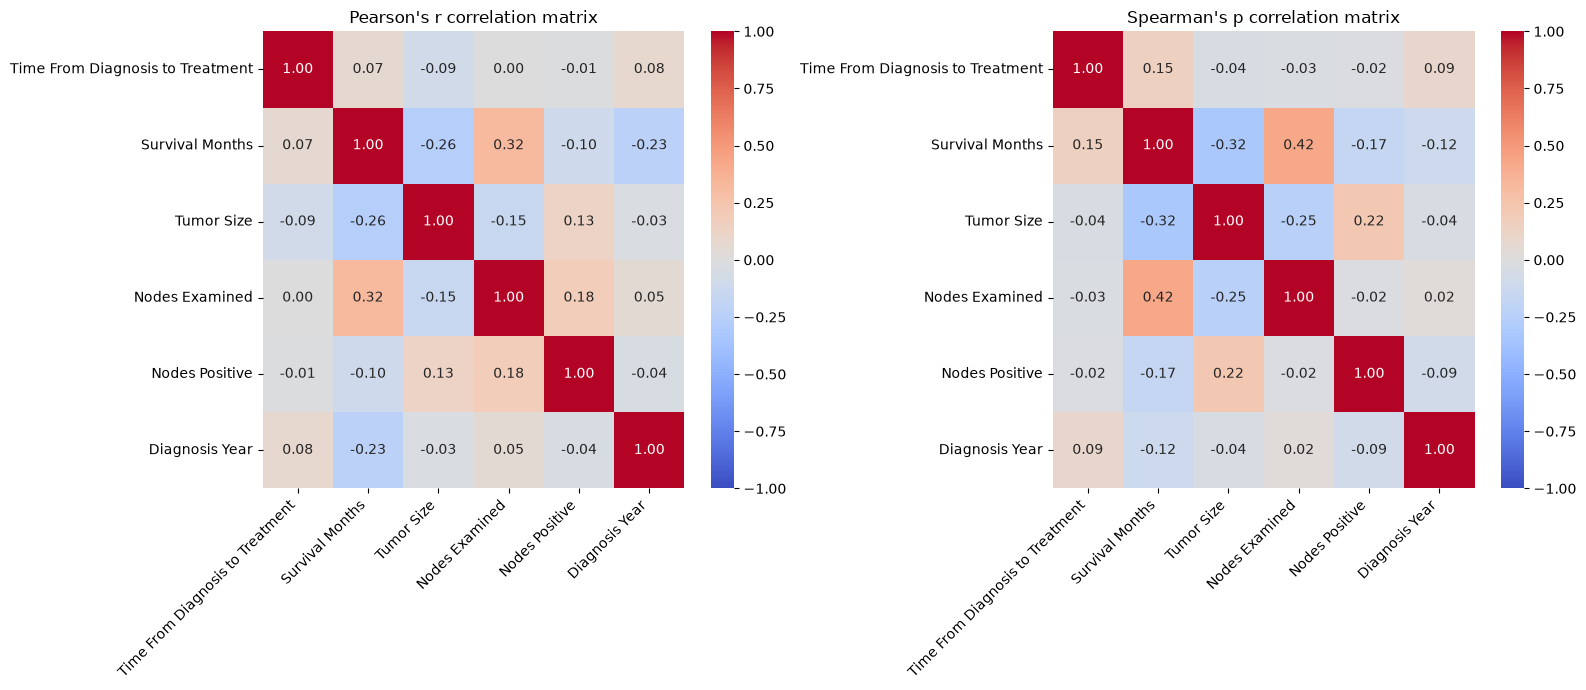

In [14]:
pearson = df[numerical].corr(method='pearson')
spearman = df[numerical].corr(method='spearman')

pearson = pearson.rename(
    index=numerical_labels,
    columns=numerical_labels
)

spearman = spearman.rename(
    index=numerical_labels,
    columns=numerical_labels
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    pearson,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax1
)
ax1.set_title('Pearson\'s r correlation matrix')

sns.heatmap(
    spearman,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax2
)
ax2.set_title("Spearman\'s p correlation matrix")

for ax in (ax1, ax2):
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Categorical vs Categorical

### Numerical vs Categorical

In [12]:
boxplot_categories = [
    'Sex',
    'RX Summ--Surg Prim Site (1998+)',
    'Radiation recode',
    'Chemotherapy recode (yes, no/unk)',
    'Visceral and Parietal Pleural Invasion Recode (2010+)',
    'SEER Combined Mets at DX-lung (2010+)',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)',
    'Race recode (W, B, AI, API)'
]

C:\Users\Asus\AppData\Local\Temp\ipykernel_12072\3113773984.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


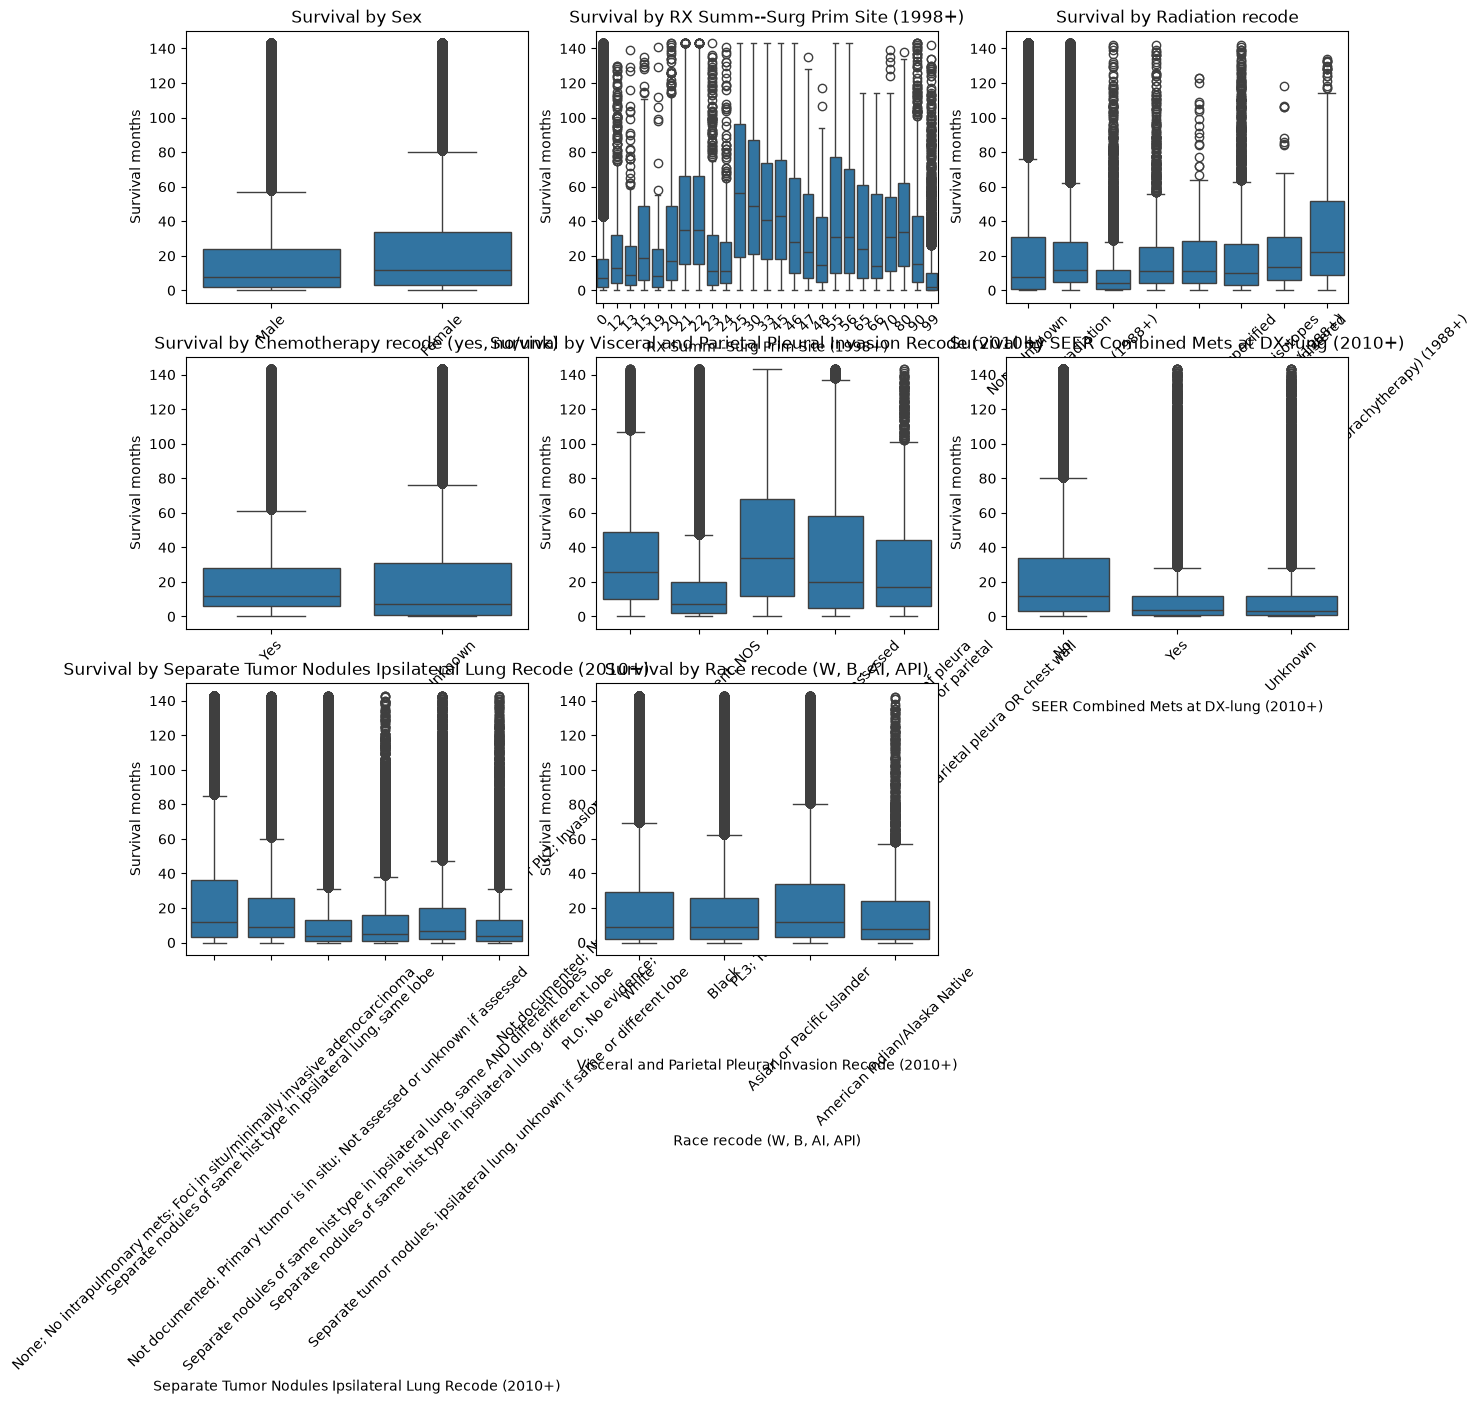

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, boxplot_categories):

    sns.boxplot(
        data=df,
        x=col,
        y='Survival months',
        ax=ax
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Survival months')
    ax.set_title(f'Survival by {col}')
    ax.tick_params(axis='x', rotation=45)

# Remove unused subplot
for ax in axes[len(boxplot_categories):]:
    ax.remove()

plt.tight_layout()
plt.show()